# PSI5123 Problem Set

Author: João Victor Colombari Carlet (5274502)

In [2]:
import sys
print(sys.executable)

!{sys.executable} -m pip -q install scipy librosa numpy matplot

/Users/joaovitor/Documents/PhD/aulas_USP/machine_learning_voz/PSI5123_problem_set/venv/bin/python

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### 1. Sketch the waveforms corresponding to the following spectrograms


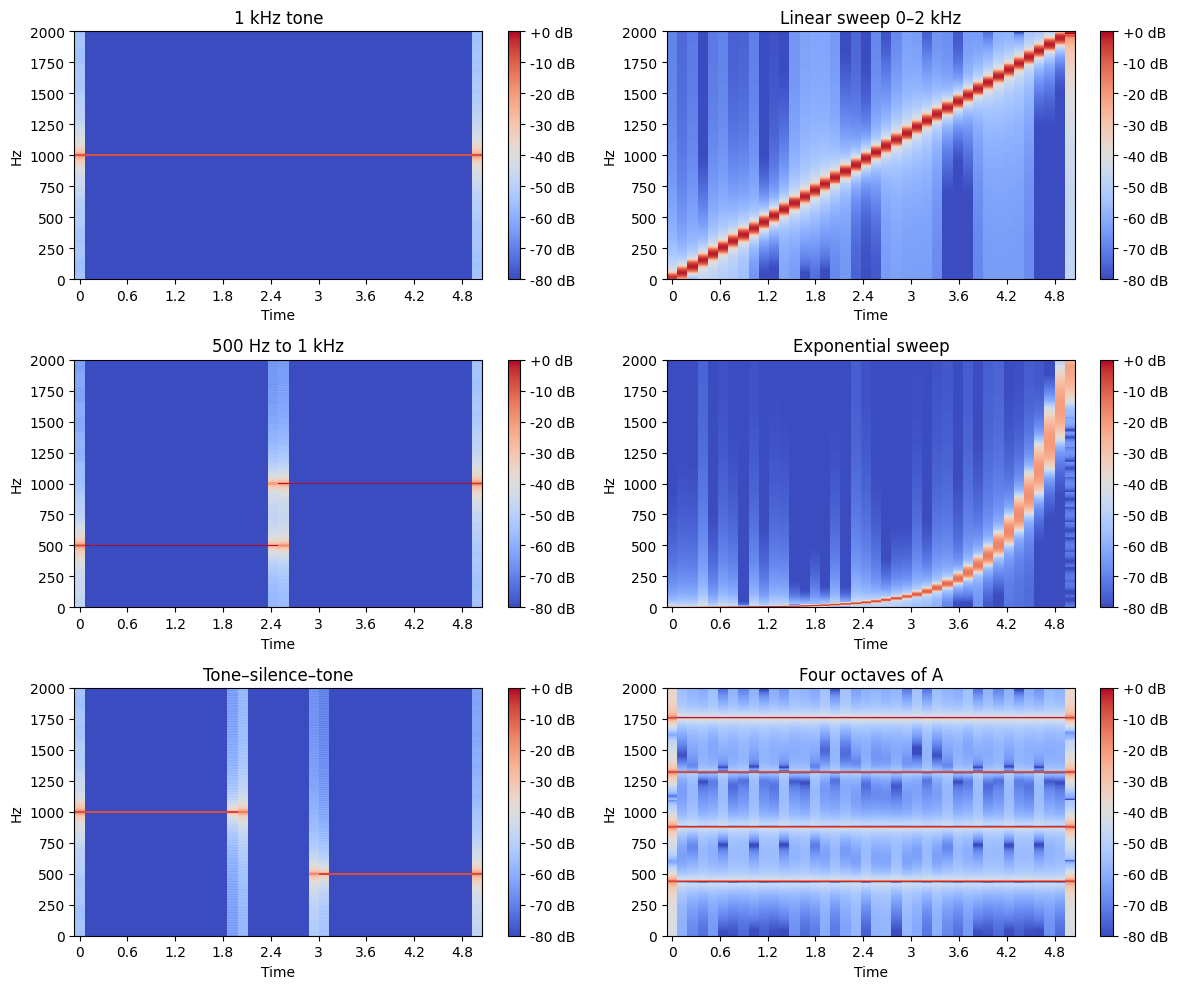

<Figure size 640x480 with 0 Axes>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

fs = 4000      
T = 5
t = np.linspace(0, T, fs*T, endpoint=False)

# -------- Signals --------
x1 = np.sin(2*np.pi*1000*t)

f_lin = np.linspace(0, 2000, len(t))
x2 = np.sin(2*np.pi * f_lin * 0.5 * t)

x3 = np.zeros_like(t)
x3[t < 2.5] = np.sin(2*np.pi*500*t[t < 2.5])
x3[t >= 2.5] = np.sin(2*np.pi*1000*t[t >= 2.5])

f0, f1 = 1, 2000
k = np.log(f1/f0) / T
phase = 2*np.pi * f0 * (np.exp(k*t) - 1) / k
x4 = np.sin(phase)

x5 = np.zeros_like(t)
x5[t < 2] = np.sin(2*np.pi*1000*t[t < 2])
x5[t >= 3] = np.sin(2*np.pi*500*t[t >= 3])

freqs = [440, 880, 1320, 1760]
x6 = sum(np.sin(2*np.pi*f*t) for f in freqs)

signals = [x1, x2, x3, x4, x5, x6]
titles = [
    "1 kHz tone",
    "Linear sweep 0–2 kHz",
    "500 Hz to 1 kHz",
    "Exponential sweep",
    "Tone–silence–tone",
    "Four octaves of A"
]

# -------- STFT parameters --------
n_window = 1024
hop_length = 512
n_fft = 1024

# -------- Plot --------
plt.figure(figsize=(12, 10))

for i, (x, title) in enumerate(zip(signals, titles), 1):
    S = librosa.stft(x, win_length=n_window, hop_length=hop_length, n_fft=n_fft, window='hamming')
    S_dB = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    plt.subplot(3, 2, i)
    img = librosa.display.specshow(
        S_dB,
        sr=fs,
        hop_length=hop_length,
        x_axis='time',
        y_axis='hz',
        cmap='coolwarm',   # blue ↔ red
        vmin=-80,
        vmax=0
    )

    plt.ylim(0, 2000)
    plt.title(title)

    # colorbar on the right
    plt.colorbar(img, format="%+2.0f dB")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

### 2. Given the spectrogram of a voice signal, determine:

a) What was the sampling frequency used?

<img src="input_figures/f1.png" width="500">

The spectrogram displays frequencies up to **4000 Hz** on the vertical axis.

Assuming this corresponds to the full bandwidth, which appears to be consistent with what is displayied in the figure, the maximum frequency shown is the Nyquist frequency:

$$ f_{max} = f_s / 2 $$

Therefore:

$$ f_s = 2 × 4000 = 8000 Hz $$

**Answer:** The sampling frequency is **8 kHz**, assuming the spectrogram is not frequency-cropped.

b) The following figure shows a zoom of the spectrogram presented in item a). Calculate the frequency resolution and the window length in number of samples. Consider, for this case, that the window size is equal to the number of samples used for the FFT.

<img src="input_figures/f2.png" width="500">

The frequency resolution of the DFT is determined by the duration of the analyzed signal:

$$\Delta f = \frac{f_s}{N} = 1/T_d, $$

where $T_d$ is the window duration in seconds. 

The zoomed figure evidently shows a resolution $\Delta f$ of 10Hz, therefore:

$$ 10 = \frac{8000}{N} \rightarrow N = 800 $$

c) Still regarding the spectrogram zoom, estimate the temporal resolution and calculate the value of the distance between segments/hop size in number of samples.

The window duration $T_d$ is 

$$ \frac{1}{T_d} = \Delta f \rightarrow T_d = \frac{1}{10} = 0.1s $$

Since each time step is equivalent to 0.05s in the spectrogram, it can be concluded that there is 50\% overlap in each window, therefore the hop size in number of samples is equal to $N/2 = 400$ samples.

### 3 - The following waveform presents the statement "The profession of flight attendant" sampled with fs = 16000Hz. Segment the waveform into regions of voiced sounds (V), voiceless/unvoiced sounds (N) and silence (S).

This description follows the classical speech production model presented in the book *Digital Processing of Speech Signals* by Rabiner, Lawrence, and Ronald Schafer. Theory and applications of digital speech processing. Prentice Hall Press, 2010.

Speech production involves multiple anatomical structures. The **vocal tract** extends from the glottis to the lips, while the **nasal tract** extends from the velum to the nostrils. In addition, the lungs and thoracic cavity play a fundamental role in generating airflow.

#### Voiced sounds (V)

Voiced sounds, including most vowels, are produced through a quasi-periodic excitation mechanism:

1. Air is drawn into the lungs.  
2. Air is expelled through the trachea, causing the vocal folds to vibrate under tension.  
3. The airflow is modulated by the opening and closing of the glottis, generating quasi-periodic pulses.  
4. These pulses are shaped in frequency by the vocal tract resonances and articulators.

The vibration mechanism arises from the interaction between muscular tension (which tends to close the vocal folds) and aerodynamic pressure (which forces them open). This cyclic process produces a quasi-periodic signal characteristic of voiced speech. There is also a slight delay between pressure buildup and sound radiation.

#### Unvoiced sounds (N)

Unvoiced (or voiceless) sounds occur when the vocal fold constriction is reduced, allowing airflow without periodic vibration. These sounds are generated by turbulence caused by constrictions in the vocal tract, particularly in the oral cavity (e.g., lips and teeth).

As a result, unvoiced sounds resemble noise-like signals (e.g., the /s/ sound in “see”).

#### Silence (S)

Silence corresponds to segments where neither voiced nor unvoiced excitation is present. These regions occur:

- Between utterances  
- Between phonemes within speech  

In practice, unvoiced regions can be difficult to distinguish from background noise, and silence is often defined as the absence of both voiced and unvoiced activity.

An illustrative example of these regions can be observed in the following figure:

<img src="input_figures/f3.png" width="500">

For annotation purposes, a simplified phoneme labeling was adopted using a one-to-one correspondence between letters and symbols (i.e., /letter/). This approach is not phonetically rigorous, but it is sufficient to guide the segmentation of voiced (V), unvoiced (N), and silence (S) regions.

A specific case occurs in the final syllable of *“aeromoça”* (“-ça”). In natural speech, the final vowel /a/ is often **reduced or devoiced**, especially in unstressed position. 

To reflect this behavior, it was annotated as **/ç(A)/**, indicating that the vowel is present at a phonological level but is **weakly realized or partially suppressed** in the acoustic signal.

<img src="input_figures/f4.png" width="500">